In [1]:
import os
import numpy as np
from astropy.io import fits
import photutils


img_path = "../test_images/173.173750_+1.621846_cube_2d.fits"
img_dat = fits.getdata(img_path)

In [2]:
from photutils.segmentation import detect_threshold
threshhold = detect_threshold(img_dat, nsigma=2.)

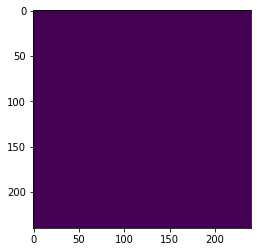

In [3]:
import matplotlib.pyplot as plt
plt.imshow(threshhold)


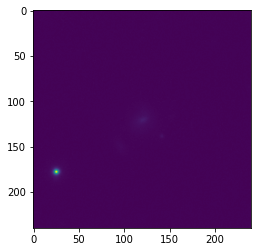

In [4]:
plt.imshow(img_dat)

In [5]:
from astropy.convolution import Gaussian2DKernel
from astropy.stats import gaussian_fwhm_to_sigma
from photutils.segmentation import detect_sources
sigma = 3.0 * gaussian_fwhm_to_sigma  # FWHM = 3
kernel = Gaussian2DKernel(sigma, x_size=3, y_size=3)
kernel.normalize()
segm = detect_sources(img_dat, threshhold, npixels=5, kernel=kernel)

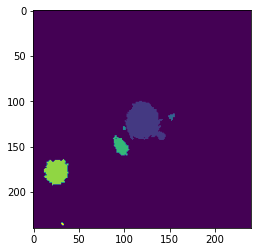

In [6]:
plt.imshow(segm)


Text(0.5, 1.0, 'Segmentation Image')

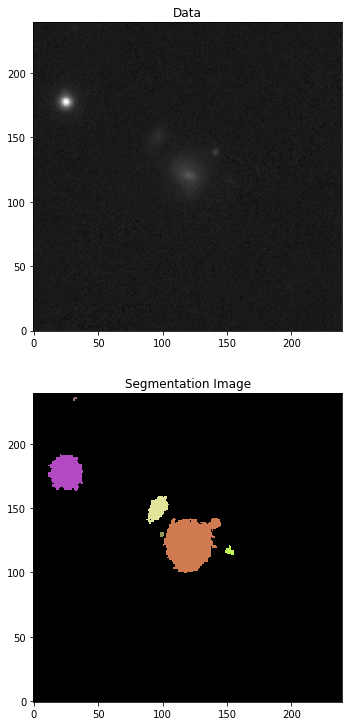

In [7]:
from astropy.visualization import SqrtStretch
from astropy.visualization.mpl_normalize import ImageNormalize
norm = ImageNormalize(stretch=SqrtStretch())
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12.5))
ax1.imshow(img_dat, origin='lower', cmap='Greys_r', norm=norm)
ax1.set_title('Data')
cmap = segm.make_cmap(seed=123)
ax2.imshow(segm, origin='lower', cmap=cmap, interpolation='nearest')
ax2.set_title("Segmentation Image")

In [8]:
from photutils.detection import DAOStarFinder
from astropy.stats import mad_std
img_dat -= np.median(img_dat)
bkg_sigma = mad_std(img_dat)
daofind = DAOStarFinder(fwhm=4., threshold=3. * bkg_sigma)

sources = daofind(img_dat)
for col in sources.colnames:
    sources[col].info.format = '%.8g'
print(sources)

 id xcentroid  ycentroid  sharpness  ... sky    peak      flux        mag     
--- --------- ----------- ---------- ... --- --------- --------- -------------
  1 47.983585 -0.15727949 0.70104174 ...   0 280.65067 1.2089908   -0.20605749
  2 74.900469   1.9193208 0.47457383 ...   0 147.45267 1.0266267  -0.028531419
  3  188.1948   2.8816582 0.51287204 ...   0  134.4091 1.0409167  -0.043539971
  4 228.98522   3.1787672 0.64748703 ...   0 257.05835 1.2099012   -0.20687478
  5 31.907973   3.5016953 0.32157383 ...   0 177.79788 1.2851614   -0.27239416
  6 55.906804   5.8480183 0.31300233 ...   0 91.332672 1.1305823   -0.13325544
  7 222.52077   5.7924869  0.6479241 ...   0 184.63097 1.0041631 -0.0045106422
  8 36.091756   13.236642 0.36883724 ...   0 132.24126 1.3864602    -0.3547685
  9 40.339752   13.270822 0.30662674 ...   0  157.7865 1.2962373   -0.28171131
 10 76.220403   12.986921 0.74359819 ...   0  286.1138 1.0589918   -0.06223153
...       ...         ...        ... ... ...       .

In [9]:
from photutils.aperture import aperture_photometry, CircularAperture
positions = np.transpose((sources['xcentroid'], sources['ycentroid']))
apertures = CircularAperture(positions, r=4.)
phot_table = aperture_photometry(img_dat, apertures)
for col in phot_table.colnames:
    phot_table[col].info.format = '%.8g'
print(phot_table)

 id  xcenter    ycenter   aperture_sum
       pix        pix                 
--- --------- ----------- ------------
  1 47.983585 -0.15727949   -1028.8918
  2 74.900469   1.9193208   -1657.2258
  3  188.1948   2.8816582    -962.3971
  4 228.98522   3.1787672    -965.4106
  5 31.907973   3.5016953    697.42728
  6 55.906804   5.8480183   -719.77663
  7 222.52077   5.7924869   -1729.9253
  8 36.091756   13.236642    1290.2082
  9 40.339752   13.270822    976.59987
 10 76.220403   12.986921    629.96106
...       ...         ...          ...
 73 224.30587   189.13286   -151.59423
 74 212.50288   189.51396   -735.20476
 75  17.05125   202.99999    1385.4115
 76 69.086934   203.87379    517.20042
 77 136.59636   205.22696   -770.34036
 78 87.698724   206.17502     -1491.64
 79  74.00614   214.58554    -1221.806
 80 158.87799   219.06625   -1423.8951
 81 2.1997925   222.14143     348.2568
 82 87.381706   221.78914   -1778.6888
Length = 82 rows


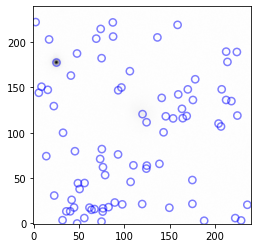

In [10]:
plt.imshow(img_dat, cmap='gray_r', origin='lower')
apertures.plot(color='blue', lw=1.5, alpha=0.5)

In [11]:
from photutils.detection import DAOStarFinder
star_tab = daofind.find_stars(img_dat)
print(star_tab)

 id     xcentroid      ...        flux                 mag         
--- ------------------ ... ------------------ ---------------------
  1  47.98358459398048 ...  1.208990801653627  -0.20605749159306053
  2  74.90046853100635 ... 1.0266267293432911  -0.02853141850262586
  3 188.19479815459997 ...   1.04091672950201  -0.04353997131656336
  4  228.9852206301805 ... 1.2099012104018672  -0.20687477800422807
  5 31.907973143133137 ... 1.2851613675811295  -0.27239415506341175
  6  55.90680442541158 ...  1.130582285134016  -0.13325544076174026
  7  222.5207680327528 ... 1.0041630967481194 -0.004510642244425218
  8 36.091755834276654 ... 1.3864601792555304  -0.35476850162938767
  9   40.3397522657923 ... 1.2962373302776808  -0.28171131130878746
 10  76.22040286173781 ... 1.0589918356818562   -0.0622315297966015
...                ... ...                ...                   ...
 72 47.872004420019685 ... 1.0227867428745565 -0.024462725415125928
 73 224.30586756258484 ...  1.182473887834109  -

In [13]:
with fits.open("../test_images/173.173750_+1.621846_cube_2d.fits") as hdul:
    hdul.info()

Filename: ../test_images/173.173750_+1.621846_cube_2d.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      20   (240, 240)   float32   
